# modkit segments v. DSS DMRs
regions of differential methylation on-the-fly using the segmenting hidden Markov model

`callDMR(DMLresult, delta=0, p.threshold=1e-5, minlen=50, minCG=3, dis.merge=100, pct.sig=0.5)`

##### Modules

In [2]:
import os
import pandas as pd
import numpy as np
from pybedtools import BedTool

import upsetplot
from matplotlib_venn import venn2, venn2_circles
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Functions

In [3]:
def AddRegion(sets, region):
    if region:  # non-empty
        memberships.append(tuple(sets))
        counts.append(len(region))

##### Fonts & Colors

In [13]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# fig size
plt.rcParams['figure.figsize'] = (7, 7)

# font size
title_size = 20
label_size = 18
tick_size = 16

colors = plt.cm.Set2.colors

##### Inputs

In [5]:
seg_cols = [
    'chrom',
    'start',
    'end',
    'state_name',
    'score',
    'n_sites',
    'a_counts',
    'b_counts',
    'a_mod_percentages',
    'b_mod_percentages',
    'a_frac_modified',
    'b_frac_modified',
    'effect_size',
    'cohen_h', 
    'cohen_h_low',
    'cohen_h_high'
]

In [6]:
REF_DIR = '/scratch/eger/projects/MethSmoothEval/tissues/ref_data'

DIR0 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/pileup'
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/dmr'
DIR2 = '/scratch/eger/projects/MethSmoothEval/tissues/DSS'
OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis'

In [7]:
# cell type indication region of the major cell types in brain and blood
ref_bed1 = os.path.join(REF_DIR, 'sniffcell_find_brain_blood.bed')

regions1 = BedTool(ref_bed1)

In [8]:
df_r1 = pd.read_csv(ref_bed1, sep='\t')
df_r1['length'] = df_r1['end'] - df_r1['start']

In [9]:
df_r1.shape

(70731, 10)

In [16]:
df_r1.head()

,#chr,start,end,name,score,strand,thickStart,thickEnd,itemRgb,length
0,chr1,109105,109488,DMR_Oligodendrocyte_hypo_vs_rest,647,.,109105,109488,0,383
1,chr1,190729,190777,DMR_Oligodendrocyte_hypo_vs_rest,850,.,190729,190777,0,48
2,chr1,191003,191308,DMR_Oligodendrocyte_hypo_vs_rest,718,.,191003,191308,0,305
3,chr1,257962,258442,DMR_B-cell_hypo_vs_rest,486,.,257962,258442,0,480
4,chr1,605137,605254,DMR_Neuron_hypo_vs_rest,475,.,605137,605254,0,117


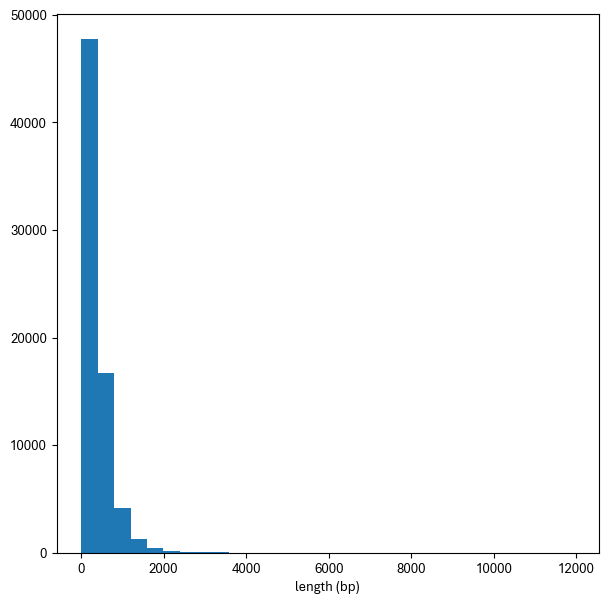

In [17]:
plt.hist(df_r1['length'], bins=30)
plt.xlabel('length (bp)')
plt.show()

In [ ]:
plt.hist(df_r1['length'])

## Bulk_FC_Control_02 v. hg002_blood

In [152]:
sample1 = 'Bulk_FC_Control_02'
sample2 = 'hg002_blood'
fname1 = os.path.join(DIR1, sample1+'_v_'+sample2+'.dmr.segments.txt')
fname2 = os.path.join(DIR2, sample1+'_v_'+sample2+'_DMLtestwSmoothing_DMRs.tsv')

df1 = pd.read_csv(fname1, sep='\t', header=None, names=seg_cols)
df1['length'] = df1['end'] - df1['start']

df2 = pd.read_csv(fname2, sep='\t')

### modkit dmr segments

#### Effect size

In [159]:
x_var = 'effect_size'
x_name = 'effect size'
start = -1
end = 1
width = 0.1

vals1 = np.array(df1[df1['state_name'] == 'same'][x_var])
vals2 = np.array(df1[df1['state_name'] == 'different'][x_var])

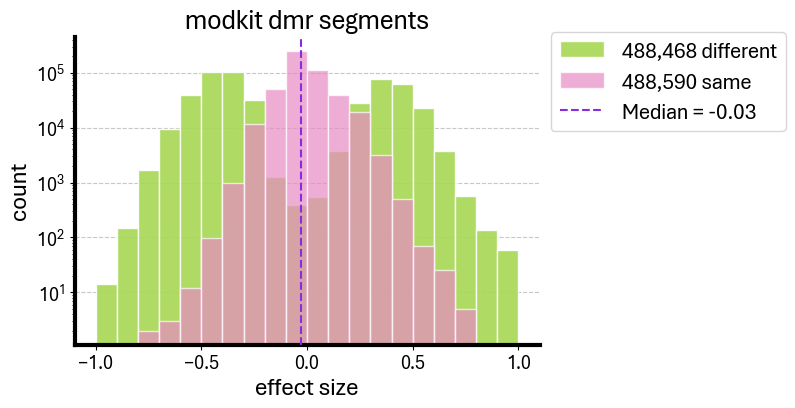

In [160]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

ax.hist(vals2, bins=np.arange(start, end + width, width),
        label=f"{len(vals2):,} different",
        alpha=0.9, color=colors[4], edgecolor='white', zorder=2)

ax.hist(vals1, bins=np.arange(start, end + width, width),
        label=f"{len(vals1):,} same",
        alpha=0.7, color=colors[3], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=14)
ax.set_ylabel('count', fontsize=18)
ax.set_xlabel(x_name, fontsize=18)

# median line
median = df1[x_var].median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}')

ax.legend(fontsize=tick_size, bbox_to_anchor=(1, 1.05))
ax.set_title('modkit dmr segments', fontsize=title_size)

plt.show()

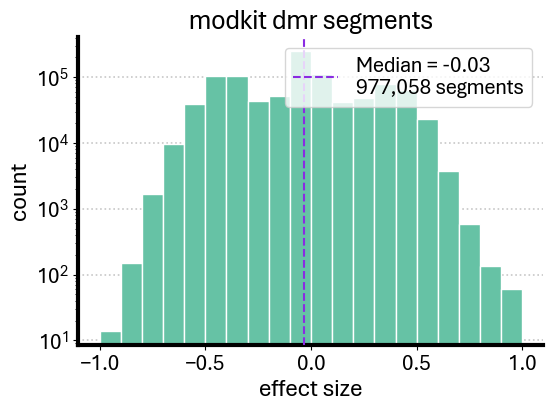

In [113]:
vals = df1['effect_size']
x_name = 'effect size'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[0], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)
    
plt.show()

#### Difference score

In [71]:
pd.DataFrame(df1['score'].describe())

,score
count,977058.000000
mean,86.573423
std,514.830572
min,-0.346558
25%,9.517504
50%,24.767368
75%,59.549697
max,203026.986802


In [162]:
x_var = 'score'
x_name = 'difference score'
start = -1e4
end = 2.2e5
width = 1e4

vals1 = np.array(df1[df1['state_name'] == 'same'][x_var])
vals2 = np.array(df1[df1['state_name'] == 'different'][x_var])

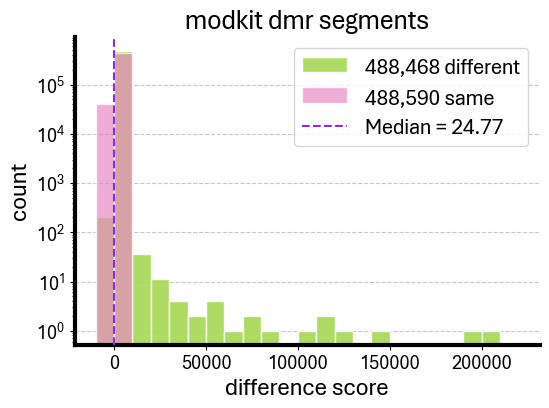

In [163]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

ax.hist(vals2, bins=np.arange(start, end + width, width),
        label=f"{len(vals2):,} different",
        alpha=0.9, color=colors[4], edgecolor='white', zorder=2)

ax.hist(vals1, bins=np.arange(start, end + width, width),
        label=f"{len(vals1):,} same",
        alpha=0.7, color=colors[3], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=14)
ax.set_ylabel('count', fontsize=18)
ax.set_xlabel(x_name, fontsize=18)

# median line
median = df1[x_var].median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}')

ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)

plt.show()

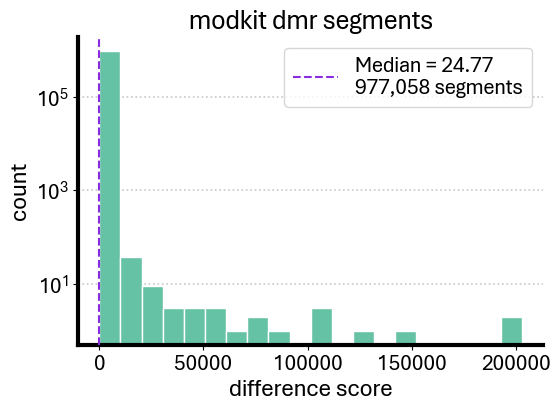

In [118]:
# difference score, more positive values have increased difference
vals = df1['score']
x_name = 'difference score'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[0], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)
    
plt.show()

#### N sites

In [164]:
x_var = 'n_sites'
x_name = 'N sites'
start = 0
end = 4000
width = 200

vals1 = np.array(df1[df1['state_name'] == 'same'][x_var])
vals2 = np.array(df1[df1['state_name'] == 'different'][x_var])

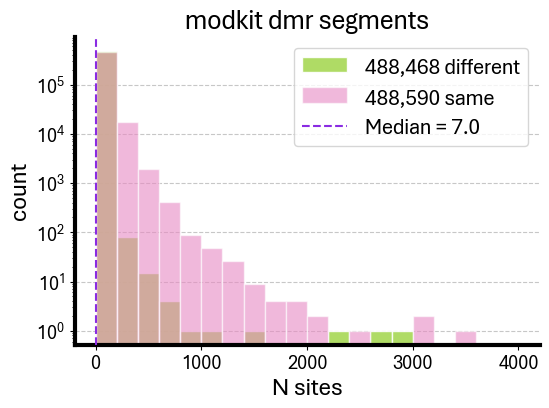

In [165]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=0)

ax.hist(vals2, bins=np.arange(start, end + width, width),
        label=f"{len(vals2):,} different",
        alpha=0.9, color=colors[4], edgecolor='white', zorder=2)

ax.hist(vals1, bins=np.arange(start, end + width, width),
        label=f"{len(vals1):,} same",
        alpha=0.6, color=colors[3], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.tick_params(axis='both', labelsize=14)
ax.set_ylabel('count', fontsize=18)
ax.set_xlabel(x_name, fontsize=18)

# median line
median = df1[x_var].median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}')

ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)

plt.show()

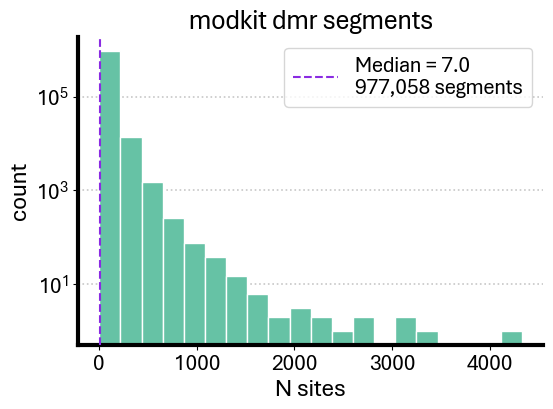

In [129]:
# difference score, more positive values have increased difference
vals = df1['n_sites']
x_name = 'N sites'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[0], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)
    
plt.show()

#### Length

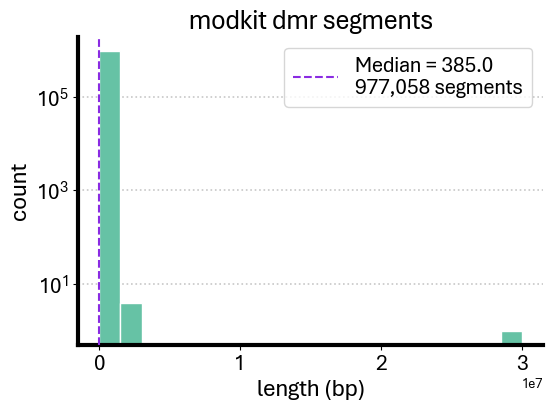

In [151]:
# difference score, more positive values have increased difference
vals = df1['length']
x_name = 'length (bp)'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[0], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)
    
plt.show()

#### Threshold for the 'different' segments

In [173]:
df3 = df1[(df1['state_name'] == 'different') & (df1['n_sites'] >= 3) & (df1['length'] >= 50)]
df3.shape

(252209, 17)

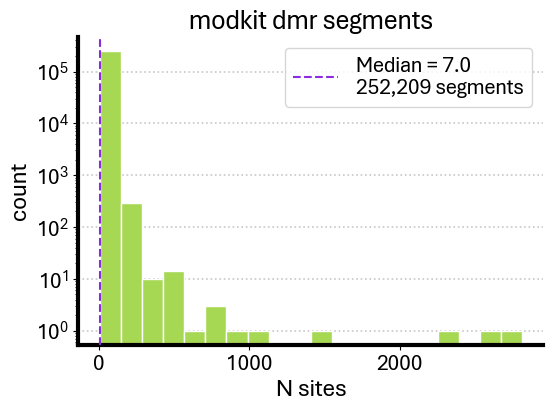

In [187]:
# difference score, more positive values have increased difference
vals = df3['n_sites']
x_name = 'N sites'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[4], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)
    
plt.show()

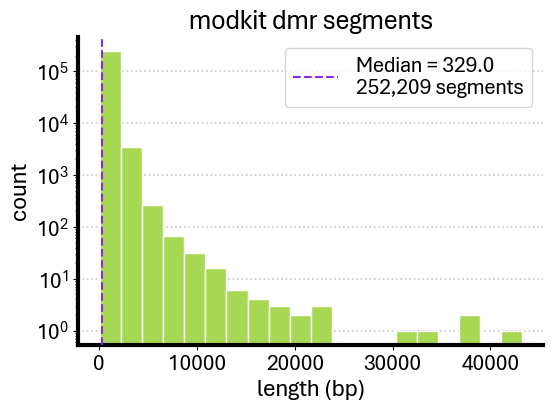

In [189]:
# difference score, more positive values have increased difference
vals = df3['length']
x_name = 'length (bp)'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[4], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('modkit dmr segments', fontsize=title_size)
    
plt.show()

### DSS DMRs

#### effect size

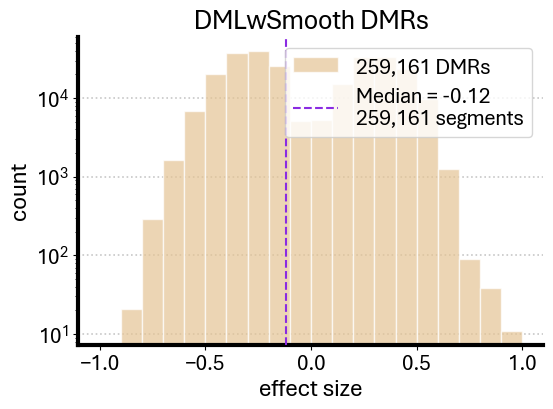

In [169]:
vals = df2['diff.Methy']
x_name = 'effect size'
start = -1
end = 1
width = 0.1

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, bins=np.arange(start, end + width, width),
        label=f"{len(vals):,} DMRs",
        alpha=0.7, color=colors[6], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} segments')
ax.legend(fontsize=tick_size)
ax.set_title('DMLwSmooth DMRs', fontsize=title_size)
    
plt.show()

In [205]:
vals1 = df3['effect_size']
vals2 = df2['diff.Methy']
x_name = 'effect size'

start = -1
end = 1
width = 0.1

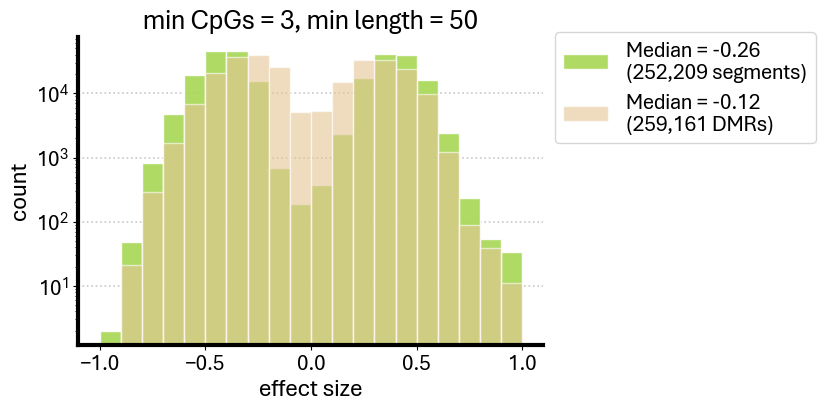

In [208]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

# get medians
median1 = vals1.median()
median2 = vals2.median()

ax.hist(vals1, bins=np.arange(start, end + width, width),
        label=f"Median = {median1:.2f} \n({len(vals1):,} segments)",
        alpha=0.9, color=colors[4], edgecolor='white', zorder=2)

ax.hist(vals2, bins=np.arange(start, end + width, width),
        label=f"Median = {median2:.2f} \n({len(vals2):,} DMRs)",
        alpha=0.6, color=colors[6], edgecolor='white', zorder=2)


ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

ax.legend(fontsize=tick_size, bbox_to_anchor=(1, 1.05))
ax.set_title('min CpGs = 3, min length = 50', fontsize=title_size)
    
plt.show()

#### areaStat

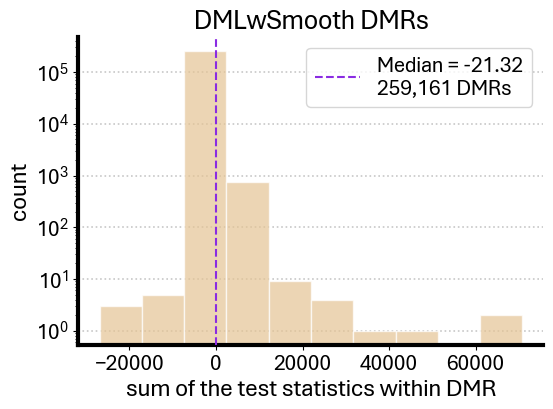

In [184]:
vals = df2['areaStat']
x_name = 'sum of the test statistics within DMR'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals,
        alpha=0.7, color=colors[6], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} DMRs')
ax.legend(fontsize=tick_size)
ax.set_title('DMLwSmooth DMRs', fontsize=title_size)
    
plt.show()

#### N CpGs

In [209]:
vals1 = df3['n_sites']
vals2 = df2['nCG']
x_name = 'N CpGs'

start = 0
end = 3000
width = 200

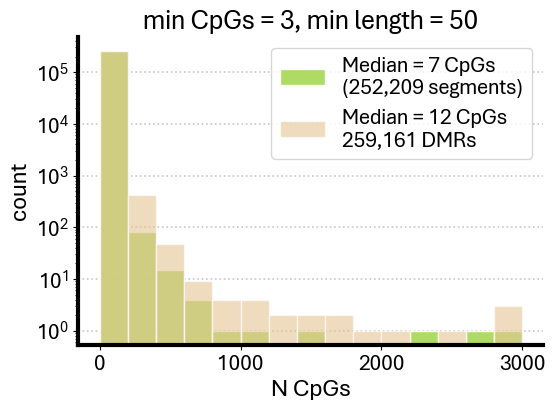

In [210]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

# get medians
median1 = vals1.median()
median2 = vals2.median()

ax.hist(vals1, bins=np.arange(start, end + width, width),
        label=f"Median = {median1:.0f} CpGs\n({len(vals1):,} segments)",
        alpha=0.9, color=colors[4], edgecolor='white', zorder=2)

ax.hist(vals2, bins=np.arange(start, end + width, width),
        label=f"Median = {median2:.0f} CpGs\n{len(vals2):,} DMRs",
        alpha=0.6, color=colors[6], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

ax.legend(fontsize=tick_size)
ax.set_title('min CpGs = 3, min length = 50', fontsize=title_size)
    
plt.show()

#### Length (bp)

In [214]:
vals1 = df3['length']
vals2 = df2['length']
x_name = 'length (bp)'

start = 0
end = 40000
width = 2000

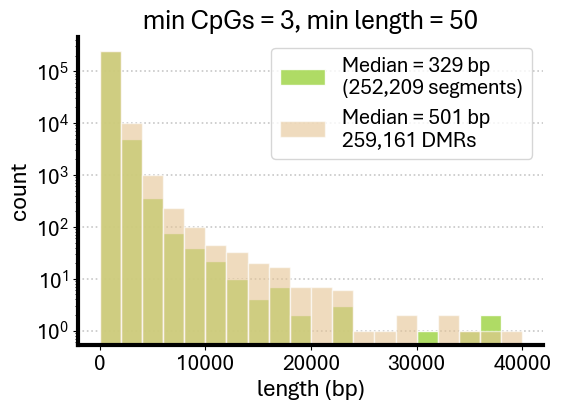

In [215]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

# get medians
median1 = vals1.median()
median2 = vals2.median()

ax.hist(vals1, bins=np.arange(start, end + width, width),
        label=f"Median = {median1:.0f} bp\n({len(vals1):,} segments)",
        alpha=0.9, color=colors[4], edgecolor='white', zorder=2)

ax.hist(vals2, bins=np.arange(start, end + width, width),
        label=f"Median = {median2:.0f} bp\n{len(vals2):,} DMRs",
        alpha=0.6, color=colors[6], edgecolor='white', zorder=2)

ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

ax.legend(fontsize=tick_size)
ax.set_title('min CpGs = 3, min length = 50', fontsize=title_size)
    
plt.show()

In [218]:
print(df3['length'].sum(), df2['length'].sum())

126423732 185147413


### Overlaps

Make bed files

In [227]:
out_bed1 = os.path.join(OUTDIR, sample1+'_v_'+sample2+'.segments.50bp_3CpG.bed')
out_bed2 = os.path.join(OUTDIR, sample1+'_v_'+sample2+'.DMRs.50bp_3CpG.bed')

df3[['chrom', 'start', 'end']].to_csv(out_bed1, sep='\t', index=False, header=False)
df2[['chr', 'start', 'end']].to_csv(out_bed2, sep='\t', index=False, header=False)

In [228]:
A = BedTool(out_bed1)
B = BedTool(out_bed2)

Minimum 20% overlap

In [240]:
df_A_B = pd.read_table(A.intersect(B, u=True, f=0.2).fn, names=['chr', 'start', 'end'])
df_B_A = pd.read_table(B.intersect(A, u=True, f=0.2).fn, names=['chr', 'start', 'end'])

print(df_A_B.shape[0], df_B_A.shape[0])

212693 176547


In [242]:
n_seg_overlap = df_A_B.shape[0]
n_seg_total = df3.shape[0]
n_dmr_overlap = df_B_A.shape[0]
n_dmr_total = df2.shape[0]

# Derived counts
seg_no = n_seg_total - n_seg_overlap
dmr_no = n_dmr_total - n_dmr_overlap

labels = ["Segments", "DMRs"]

overlap_counts = np.array([n_seg_overlap, n_dmr_overlap])
no_counts      = np.array([seg_no, dmr_no])

# Compute percentages for labeling
overlap_pct = overlap_counts / (overlap_counts + no_counts) * 100
no_pct      = 100 - overlap_pct

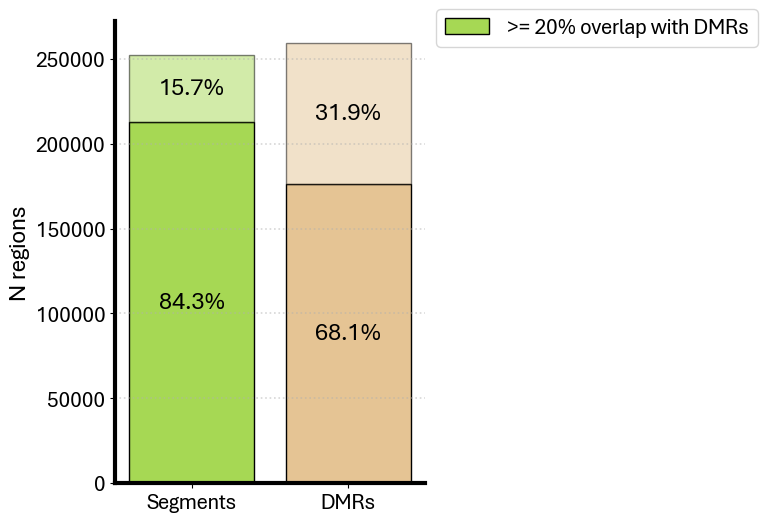

In [262]:
fig, ax = plt.subplots(figsize=(4, 6))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

# Stacked bars: bottom = overlaps, top = non-overlaps
bars1 = ax.bar(labels, overlap_counts, label='>= 20% overlap with DMRs',
               color=[colors[4], colors[6]], edgecolor='black')
bars2 = ax.bar(labels, no_counts, bottom=overlap_counts, 
               color=[colors[4], colors[6]], edgecolor='black', alpha=0.5)

# ---- Add percentage labels ----
for i in range(len(labels)):
    # Overlap % (center of lower segment)
    ax.text(i, overlap_counts[i] / 2,
            f"{overlap_pct[i]:.1f}%",
            ha="center", va="center", fontsize=label_size)

    # No-overlap % (center of top segment)
    ax.text(i, overlap_counts[i] + no_counts[i] / 2,
            f"{no_pct[i]:.1f}%",
            ha="center", va="center", fontsize=label_size)

ax.set_ylabel("N regions", fontsize=label_size)
ax.legend(fontsize=tick_size, bbox_to_anchor=(1, 1.05))

plt.show()

In [263]:
df_A_reg1 = pd.read_table(A.intersect(regions1, u=True, f=0.2).fn, names=['chr', 'start', 'end'])
df_B_reg1 = pd.read_table(B.intersect(regions1, u=True, f=0.2).fn, names=['chr', 'start', 'end'])
print(df_A_reg1.shape[0], df_B_reg1.shape[0])

30515 29994


In [279]:
print(f'{df_A_reg1.shape[0]:,}/{n_seg_total:,} segments have min 20% overlap with celltype regions = {df_A_reg1.shape[0]/n_seg_total*100:1f}%')
print(f'{df_B_reg1.shape[0]:,}/{n_dmr_total:,} segments have min 20% overlap with celltype regions = {df_B_reg1.shape[0]/n_dmr_total*100:1f}%')

30,515/252,209 segments have min 20% overlap with celltype regions = 12.099092%
29,994/259,161 segments have min 20% overlap with celltype regions = 11.573501%


In [274]:
df_reg1_A = pd.read_table(regions1.intersect(A, u=True, f=0.2).fn, names=df_r1.columns[:-1])
df_reg1_B = pd.read_table(regions1.intersect(B, u=True, f=0.2).fn, names=df_r1.columns[:-1])
print(df_reg1_A.shape[0], df_reg1_B.shape[0])

33142 40684


In [280]:
df_reg1_A.index = df_reg1_A['#chr']+':'+df_reg1_A['start'].astype(str)
df_reg1_B.index = df_reg1_B['#chr']+':'+df_reg1_B['start'].astype(str)

In [282]:
reg1_A = set(df_reg1_A.index)
reg1_B = set(df_reg1_B.index)

A_only = reg1_A - reg1_B
B_only = reg1_B - reg1_A
AB    = reg1_A & reg1_B

memberships = []
counts = []

AddRegion(['segments'],      A_only)
AddRegion(['DMRs'],      B_only)
AddRegion(['segments','DMRs'],  AB)

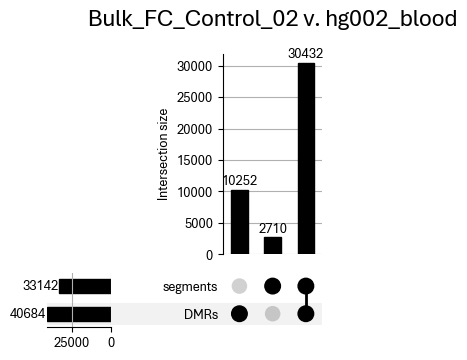

In [283]:
data = upsetplot.from_memberships(memberships, data=counts)
plot_result = upsetplot.plot(data, show_counts=True)

plt.title("Bulk_FC_Control_02 v. hg002_blood", fontsize=label_size, pad=20)
plt.show()